# ISLP Chapter 11 Lab: Survival Analysis and Censored Data

**Text:** *An Introduction to Statistical Learning with Applications in Python*, 11.8

Survival analysis handles a specific and common problem: the outcome is a **time until an event**,
and for some observations the event has not happened yet when the study ends. Those observations
are **censored** we know the patient survived at least 40 months, not how long they actually
survived.

Neither obvious shortcut works. Dropping censored observations throws away the longest survivors
and biases everything downward. Treating the censoring time as the event time pretends people died
when they didn't. The methods in this chapter use the partial information correctly.

| Section | Data | Method |
|---|---|---|
| 11.8.1 | `BrainCancer` | Kaplan-Meier curves, log-rank test, Cox model |
| 11.8.2 | `Publication` | Cox model what happens when confounders are added |
| 11.8.3 | Simulated call center | Simulating from a Cox model and recovering the truth |

Despite the medical framing, the "event" is anything with a time-to-occurrence and incomplete
follow-up: customer churn, loan default, machine failure, time to employment, or as in §11.8.3 how long a caller waits on hold.

**Requirements:** `ISLP`, `lifelines` (`pip install lifelines`), `pandas`, `numpy`, `matplotlib`.

---
## Setup

In [1]:
from matplotlib.pyplot import subplots
import numpy as np
import pandas as pd
from ISLP.models import ModelSpec as MS
from ISLP import load_data

`lifelines` is the main survival package. `KaplanMeierFitter` estimates survival curves without
assuming any model; `CoxPHFitter` fits the proportional hazards regression. The two log-rank
functions test whether curves differ across groups, and `sim_time` is an ISLP helper used to
simulate survival times in §11.8.3.

In [2]:
from lifelines import \
     (KaplanMeierFitter,
      CoxPHFitter)
from lifelines.statistics import \
     (logrank_test,
      multivariate_logrank_test)
from ISLP.survival import sim_time

---
## 11.8.1 Brain Cancer Data

88 patients with brain tumors. `time` is months of follow-up and `status` is the event indicator.

In [3]:
BrainCancer = load_data('BrainCancer')
BrainCancer.columns

Index(['sex', 'diagnosis', 'loc', 'ki', 'gtv', 'stereo', 'status', 'time'], dtype='object')

In [4]:
BrainCancer['sex'].value_counts()

sex
Female    45
Male      43
Name: count, dtype: int64

In [5]:
BrainCancer['diagnosis'].value_counts()

diagnosis
Meningioma    42
HG glioma     22
Other         14
LG glioma      9
Name: count, dtype: int64

### Check the coding of `status` first

This is the single most important thing to verify before any survival analysis. The near-universal
convention is:

- **`status = 1`** → event observed (here, death)
- **`status = 0`** → censored (still alive at last follow-up, or lost to follow-up)

But the opposite coding does appear in the wild, and getting it backwards inverts every result
silently — no error, just a survival curve that is wrong in the most damaging possible way. Here
53 patients are censored and 35 died, which fits the conventional coding for a study where most
patients survive.

Check this against the data dictionary every time, not just against what looks plausible.

In [6]:
BrainCancer['status'].value_counts()

status
0    53
1    35
Name: count, dtype: int64

### The Kaplan-Meier estimator

The survival function is $S(t) = \Pr(T > t)$, the probability of surviving beyond time $t$. The
Kaplan-Meier estimator computes it as a product over observed event times:

$$\hat S(t) = \prod_{j:\, t_j \le t} \left(\frac{r_j - d_j}{r_j}\right),$$

where $d_j$ is the number of deaths at time $t_j$ and $r_j$ the number still at risk just before
it. Censored observations contribute to $r_j$ up until they are censored, then drop out of the
risk set — which is exactly how their partial information is used without pretending we know more
than we do.

The result is a step function that only drops at observed deaths. It assumes **independent
censoring**: the reason someone is censored is unrelated to their prognosis. That assumption
fails, for example, if the sickest patients leave a study early, and no amount of data fixes it
— it is untestable from the data alone.

Note `lifelines` plots **90%** confidence intervals by default, not 95%. Set
`alpha=0.05` for 95%.

<Axes: xlabel='timeline'>

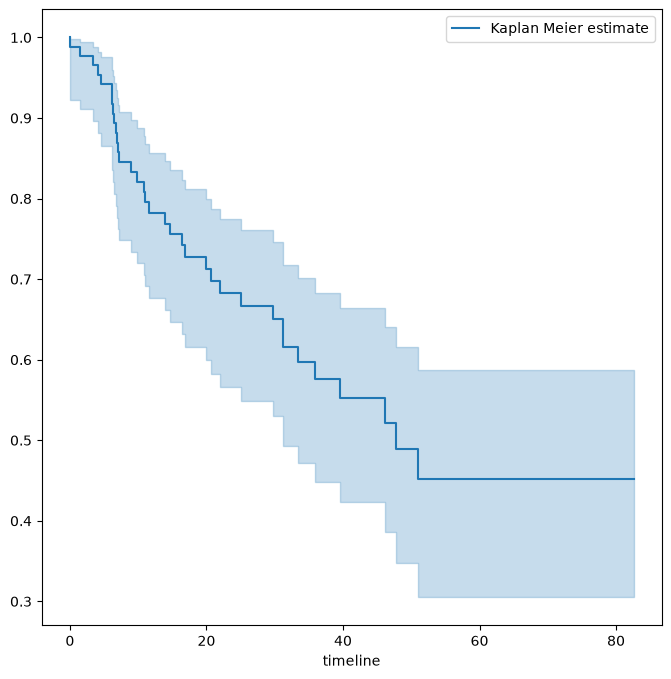

In [7]:
fig, ax = subplots(figsize=(8,8))
km = KaplanMeierFitter()
km_brain = km.fit(BrainCancer['time'], BrainCancer['status'])
km_brain.plot(label='Kaplan Meier estimate', ax=ax)

### Stratifying by sex

Fitting a separate curve per group is the standard first comparison. `groupby` yields
`(value, sub-dataframe)` pairs; the sub-frames are stored in `by_sex` because the log-rank test
needs them next.

The bands widen at the right-hand end of any KM plot, because few patients remain at risk that
late. Late-time differences between curves are usually not what they appear to be.

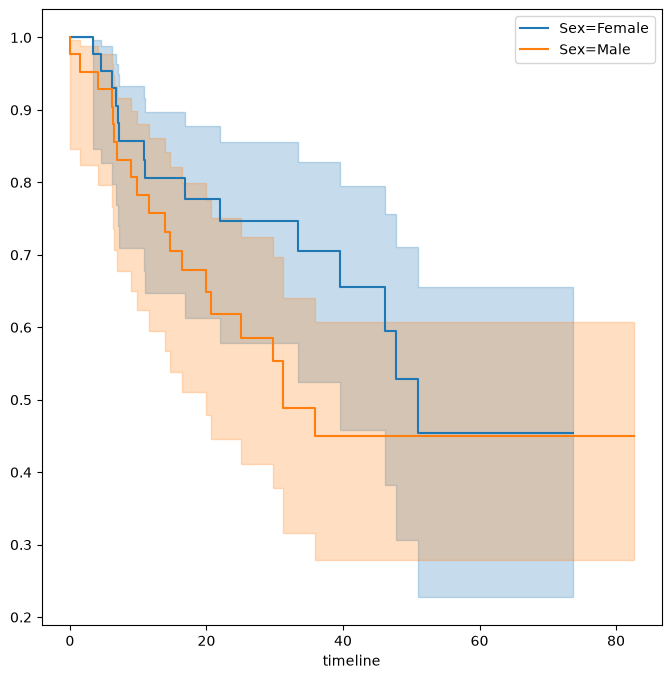

In [8]:
fig, ax = subplots(figsize=(8,8))
by_sex = {}
for sex, df in BrainCancer.groupby('sex', observed=True):
    by_sex[sex] = df
    km_sex = km.fit(df['time'], df['status'])
    km_sex.plot(label='Sex=%s' % sex, ax=ax)

### The log-rank test

Comparing two survival curves cannot be done with a t-test — censoring makes the mean survival
time unidentifiable. The log-rank test instead compares, at each event time, the observed number
of deaths in a group against the number expected if the two groups had identical hazards, then
aggregates into a $\chi^2$ statistic.

Argument order matters: durations first (both groups), then the corresponding event indicators.

$p = 0.23$, so there is no evidence of a survival difference between the sexes. Note this is not
evidence they are the same — with 88 patients and 35 events, only a large difference would be
detectable.

In [9]:
logrank_test(by_sex['Male']['time'],
             by_sex['Female']['time'],
             by_sex['Male']['status'],
             by_sex['Female']['status'])

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           1.44 0.23      2.12

### The Cox proportional hazards model

The Cox model is regression for censored outcomes. It models the **hazard** — the instantaneous
risk of the event at time $t$, given survival up to $t$:

$$h(t \mid x_i) = h_0(t)\, \exp\!\left(\beta_1 x_{i1} + \dots + \beta_p x_{ip}\right).$$

Two features make it the workhorse of the field:

- The **baseline hazard** $h_0(t)$ is left completely unspecified. No distributional assumption
  about survival times is needed, which is why the model is semi-parametric.
- The covariate effects are **multiplicative and constant over time** — the proportional hazards
  assumption. $e^{\beta_j}$ is the hazard ratio per unit increase in $x_j$: above 1 means higher
  risk and shorter survival, below 1 means lower risk.

The $\beta$'s are estimated from the *partial* likelihood, which conditions on the risk set at
each event time and so never requires $h_0(t)$.

**There is no intercept** — it would be absorbed into $h_0(t)$ — hence `intercept=False`.
`coxph = CoxPHFitter` is just a shorthand for the class, so `coxph()` creates an instance.

In [10]:
coxph = CoxPHFitter # shorthand
sex_df = BrainCancer[['time', 'status', 'sex']]
model_df = MS(['time', 'status', 'sex'],
              intercept=False).fit_transform(sex_df)
cox_fit = coxph().fit(model_df,
                      'time',
                      'status')
cox_fit.summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
sex[Male],0.407668,0.342004,0.233262


The coefficient for `sex[Male]` is 0.408, so $e^{0.408} \approx 1.50$ — males have about a 50%
higher hazard — but $p = 0.23$, so this is not distinguishable from zero.

The likelihood ratio test gives a statistic of 1.44 and $p = 0.23$: **identical to the log-rank
test above**. That is not a coincidence. The log-rank statistic is exactly the score test from a
Cox model with a single binary covariate. The two procedures are the same method viewed from
different angles — which is worth knowing, since it means the Cox model generalizes the log-rank
test to continuous predictors and multiple covariates.

In [11]:
cox_fit.log_likelihood_ratio_test()

<lifelines.StatisticalResult: log-likelihood ratio test>
null_distribution = chi squared
  degrees_freedom = 1
        test_name = log-likelihood ratio test

---
 test_statistic    p  -log2(p)
           1.44 0.23      2.12

### Adding predictors

One `diagnosis` value is missing, so that row is dropped. Worth noting the cost: `dropna()` on the
full frame removes an observation entirely, and if missingness were related to prognosis this
would bias the results. With one row out of 88 it is immaterial; with many it would need proper
handling.

In [12]:
cleaned = BrainCancer.dropna()
all_MS = MS(cleaned.columns, intercept=False)
all_df = all_MS.fit_transform(cleaned)
fit_all = coxph().fit(all_df,
                      'time',
                      'status')
fit_all.summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
sex[Male],0.183748,0.360358,0.610119
diagnosis[LG glioma],-1.239530,0.579555,0.032455
diagnosis[Meningioma],-2.154566,0.450524,0.000002
diagnosis[Other],-1.268870,0.617672,0.039949
loc[Supratentorial],0.441195,0.703669,0.530665
ki,-0.054955,0.018314,0.002693
gtv,0.034293,0.022333,0.124661
stereo[SRT],0.177778,0.601578,0.767597


Reading the output:

- **`diagnosis`** has HG glioma as the baseline level. Meningioma's coefficient is $-2.15$, so
  $e^{-2.15} \approx 0.12$ — meningioma patients have roughly one-eighth the hazard. Inverted,
  HG glioma carries about $e^{2.15} \approx 8.6$ times the risk of meningioma, adjusting for
  everything else. This is the dominant effect in the model.
- **`ki`** (Karnofsky performance index, higher = better functioning) has coefficient $-0.055$,
  $p = 0.003$. Each additional point multiplies the hazard by $e^{-0.055} \approx 0.95$. Ten
  points gives $e^{-0.55} \approx 0.58$ — a 42% reduction in hazard.
- **`gtv`**, **`sex`**, **`loc`**, **`stereo`** are not significant here.

Always exponentiate before interpreting. A coefficient of $-0.055$ means nothing on its own; a
hazard ratio of 0.95 per point is a statement a clinician can use.

### Adjusted survival curves

To display the effect of `diagnosis`, the other predictors must be held fixed at representative
values — means for quantitative variables, the mode for categorical ones. Otherwise the four
curves would differ for reasons unrelated to diagnosis.

A note on the book's comment here: it describes `apply(..., axis=0)` as applying "across rows",
which is the wrong way round. `axis=0` applies the function to **each column**, which is what is
wanted — `representative` receives one column at a time.

In [13]:
levels = cleaned['diagnosis'].unique()
def representative(series):
    if hasattr(series.dtype, 'categories'):
        return pd.Series.mode(series)
    else:
        return series.mean()
modal_data = cleaned.apply(representative, axis=0)
modal_data

,sex,diagnosis,loc,ki,gtv,stereo,status,time
0,Female,Meningioma,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621


Four identical rows of representative values, differing only in `diagnosis`. The `.iloc[0]` picks
the single row out of what `apply` returned — `pd.Series.mode` returns a Series rather than a
scalar, so the result comes back with an extra dimension.

In [14]:
modal_df = pd.DataFrame(
              [modal_data.iloc[0] for _ in range(len(levels))])
modal_df['diagnosis'] = levels
modal_df

,sex,diagnosis,loc,ki,gtv,stereo,status,time
0,Female,Meningioma,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621
0,Female,HG glioma,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621
0,Female,LG glioma,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621
0,Female,Other,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621


The new data must be transformed by the **same** `ModelSpec` used to fit the model, so the dummy
coding and column order match exactly. Building a design matrix independently is a reliable way to
get silently wrong predictions.

In [15]:
modal_X = all_MS.transform(modal_df)
modal_X.index = levels
modal_X

,sex[Male],diagnosis[LG glioma],diagnosis[Meningioma],diagnosis[Other],loc[Supratentorial],ki,gtv,stereo[SRT],status,time
Meningioma,0.0,0.0,1.0,0.0,1.0,80.91954,8.687011,1.0,0.402299,27.188621
HG glioma,0.0,0.0,0.0,0.0,1.0,80.91954,8.687011,1.0,0.402299,27.188621
LG glioma,0.0,1.0,0.0,0.0,1.0,80.91954,8.687011,1.0,0.402299,27.188621
Other,0.0,0.0,0.0,1.0,1.0,80.91954,8.687011,1.0,0.402299,27.188621


In [16]:
predicted_survival = fit_all.predict_survival_function(modal_X)
predicted_survival

,Meningioma,HG glioma,LG glioma,Other
0.07,0.997947,0.982430,0.994881,0.995029
1.18,0.997947,0.982430,0.994881,0.995029
1.41,0.995679,0.963342,0.989245,0.989555
1.54,0.995679,0.963342,0.989245,0.989555
2.03,0.995679,0.963342,0.989245,0.989555
...,...,...,...,...
65.02,0.688772,0.040136,0.394181,0.404936
67.38,0.688772,0.040136,0.394181,0.404936
73.74,0.688772,0.040136,0.394181,0.404936
78.75,0.688772,0.040136,0.394181,0.404936


The four curves show the proportional hazards structure directly: they never cross. That is a
consequence of the model, not a finding in the data — under proportional hazards, one group's
curve stays below another's at all times. If the true curves *did* cross, the model would be
misspecified and the assumption would need checking (via Schoenfeld residuals, for instance).

HG glioma drops steeply, meningioma stays high — the same eight-fold difference seen in the
coefficients, now on a scale that is easier to present.

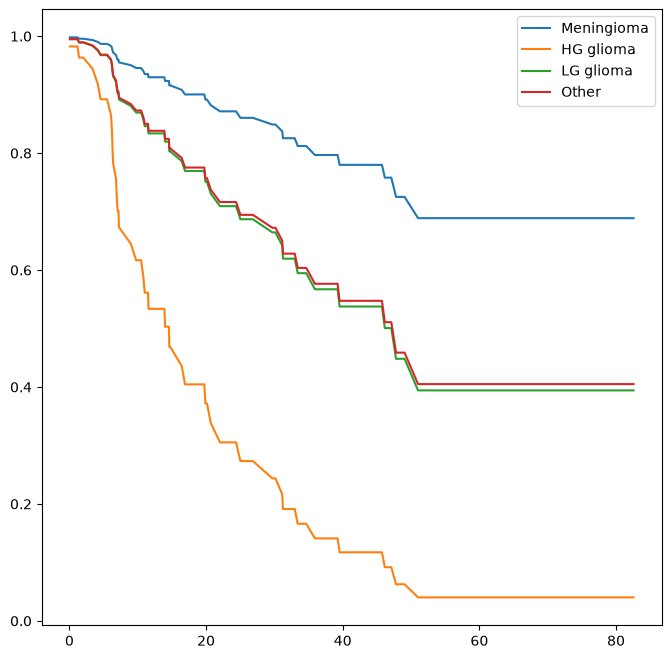

In [17]:
fig, ax = subplots(figsize=(8, 8))
predicted_survival.plot(ax=ax);

---
## 11.8.2 Publication Data

Time from completion of a clinical trial to publication of its results. The question is publication
bias: do trials with positive results (`posres = 1`) get published faster?

Note the event here is publication, not death. Censored observations are trials not yet published
at the end of follow-up.

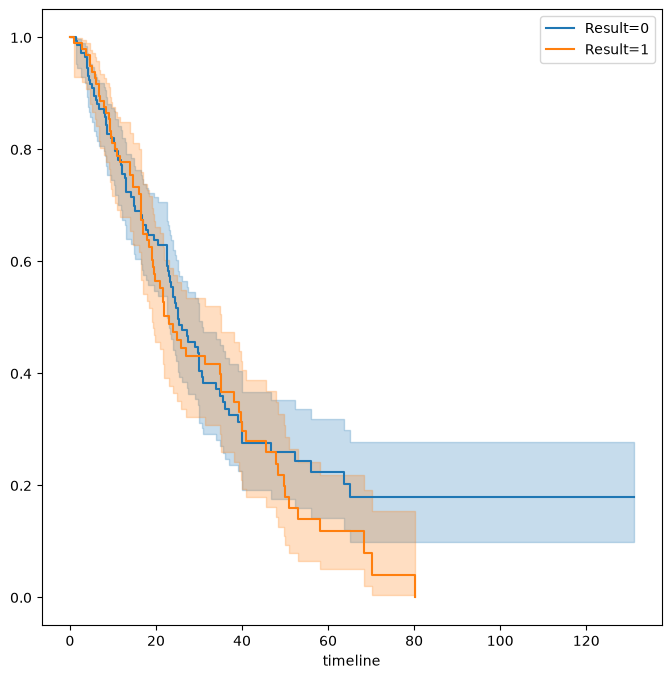

In [18]:
fig, ax = subplots(figsize=(8,8))
Publication = load_data('Publication')
by_result = {}
for result, df in Publication.groupby('posres', observed=True):
    by_result[result] = df
    km_result = km.fit(df['time'], df['status'])
    km_result.plot(label='Result=%d' % result, ax=ax)

With `posres` as the only predictor, the coefficient is 0.148 with $p = 0.36$ — no evidence of
publication bias.

In [19]:
posres_df = MS(['posres',
                'time',
                'status'],
               intercept=False).fit_transform(Publication)
posres_fit = coxph().fit(posres_df,
                         'time',
                         'status')
posres_fit.summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
posres,0.148076,0.161625,0.359579


### What happens when confounders are added

Now include the other predictors — sample size, budget, journal impact, whether the trial had a
clinical endpoint — excluding only the funding mechanism.

The `posres` coefficient goes from 0.148 ($p = 0.36$) to **0.571** ($p = 0.001$). The effect
roughly quadruples and becomes highly significant.

This is the most instructive result in the chapter, and it is a confounding story. Positive and
negative trials differ systematically in other ways — notably `impact`, which is overwhelmingly
significant ($p \approx 10^{-18}$). Those differences were masking the publication-bias effect in
the unadjusted model. Only after adjusting for them does the association with `posres` appear.

The general lesson applies well beyond survival analysis: **a null result from an unadjusted model
is not evidence of no effect.** The direction of the bias is not predictable in advance either —
adjustment can just as easily shrink an effect as inflate it. Which covariates belong in the model
is a subject-matter question, not a statistical one.

In [20]:
model = MS(Publication.columns.drop('mech'),
           intercept=False)
coxph().fit(model.fit_transform(Publication),
            'time',
            'status').summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
posres,0.570773,0.175960,1.179610e-03
multi,-0.040860,0.251194,8.707842e-01
clinend,0.546183,0.262000,3.709944e-02
sampsize,0.000005,0.000015,7.507005e-01
budget,0.004386,0.002465,7.515984e-02
impact,0.058318,0.006676,2.426306e-18


---
## 11.8.3 Call Center Data

Here the data are simulated, which makes this section unusually valuable: **the true coefficients
are known**, so the estimates can be checked against them. That is not possible with real data,
and it is the cleanest way to confirm a method actually recovers what it claims to.

The scenario: 2,000 customers on hold. The "event" is the call being answered; censoring occurs
when a customer hangs up first. Three covariates — number of operators (5–15), center (A/B/C),
and time of day.

Note the reversed intuition. A **higher** hazard means the call is answered **sooner**, so a
positive coefficient is good news for the caller.

In [21]:
rng = np.random.default_rng(10)
N = 2000

Operators = rng.choice(np.arange(5, 16),
                       N,
                       replace=True)
Center = rng.choice(['A', 'B', 'C'],
                    N,
                    replace=True)
Time = rng.choice(['Morn.', 'After.', 'Even.'],
                  N,
                  replace=True)
D = pd.DataFrame({'Operators': Operators,
                  'Center': pd.Categorical(Center),
                  'Time': pd.Categorical(Time)})

In [22]:
model = MS(['Operators',
            'Center',
            'Time'],
           intercept=False)
X = model.fit_transform(D)

Inspecting the model matrix before simulating is essential — the coefficients assigned next are
positional, so they must line up with these columns. Levels are sorted alphabetically and the
first is dropped, making `Center A` and `Time After.` the baselines.

In [23]:
X[:5]

,Operators,Center[B],Center[C],Time[Even.],Time[Morn.]
0,13,0.0,1.0,0.0,0.0
1,15,0.0,0.0,1.0,0.0
2,7,1.0,0.0,0.0,1.0
3,7,0.0,1.0,0.0,1.0
4,13,0.0,1.0,1.0,0.0


### The true model

The coefficients, in the column order printed above:

| Covariate | $\beta$ | $e^\beta$ | Meaning |
|---|---|---|---|
| `Operators` | 0.04 | 1.041 | Each extra operator raises the answer-rate 4% — shorter waits |
| `Center[B]` | −0.3 | 0.741 | Center B answers at 74% the rate of A — longer waits |
| `Center[C]` | 0 | 1.000 | No different from A |
| `Time[Even.]` | 0.2 | 1.221 | Evenings answered faster |
| `Time[Morn.]` | −0.2 | 0.819 | Mornings slower |

The baseline hazard is $h_0(t) = 10^{-5} t$, increasing with time. The cumulative hazard is its
integral, $H_0(t) = 10^{-5} t^2/2$, and `sim_time` inverts the relation $S(t) = \exp(-H(t))$ to
draw survival times. (The `hazard` lambda is defined for exposition; `sim_time` uses
`cum_hazard`.)

In [24]:
true_beta = np.array([0.04, -0.3, 0, 0.2, -0.2])
true_linpred = X.dot(true_beta)
hazard = lambda t: 1e-5 * t

In [25]:
cum_hazard = lambda t: 1e-5 * t**2 / 2

In [26]:
W = np.array([sim_time(l, cum_hazard, rng)
              for l in true_linpred])
D['Wait time'] = np.clip(W, 0, 1000)

Censoring is drawn **completely at random** — a 90/10 coin flip independent of wait time, center,
and everything else. This satisfies the independent censoring assumption by construction, which is
why the estimates below come out unbiased.

Real censoring is rarely this well behaved. If customers with long waits were more likely to hang
up, censoring would depend on the outcome and the estimates would be biased. That is the
assumption to interrogate in any applied survival analysis, and it cannot be checked from the data.

In [27]:
D['Failed'] = rng.choice([1, 0],
                         N,
                         p=[0.9, 0.1])
D[:5]

,Operators,Center,Time,Wait time,Failed
0,13,C,After.,525.064979,1
1,15,A,Even.,254.677835,1
2,7,B,Morn.,487.739224,1
3,7,C,Morn.,308.580292,1
4,13,C,Even.,154.174608,1


In [28]:
D['Failed'].mean()

np.float64(0.9075)

### Kaplan-Meier curves by group

These curves read as "probability of still being on hold" — survival here means still waiting.
Center B sits above the others, meaning callers stay on hold longer.

Text(0.5, 1.0, 'Probability of Still Being on Hold')

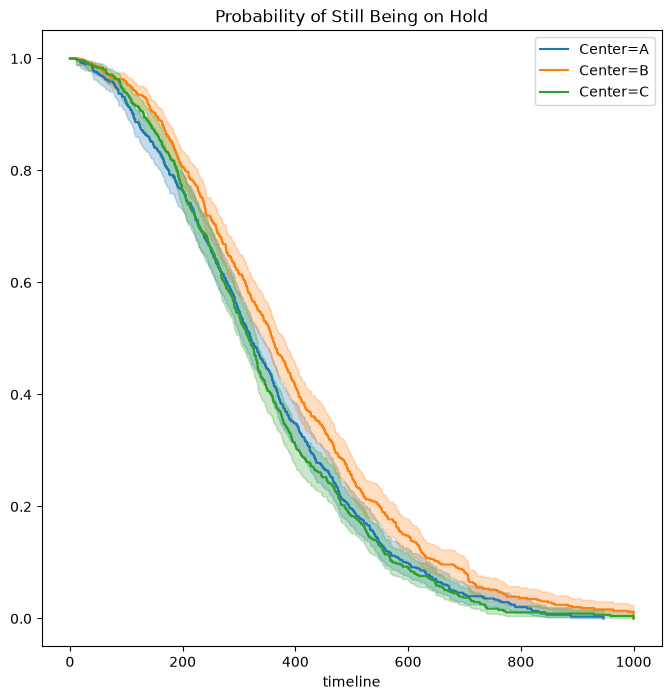

In [29]:
fig, ax = subplots(figsize=(8,8))
by_center = {}
for center, df in D.groupby('Center', observed=True):
    by_center[center] = df
    km_center = km.fit(df['Wait time'], df['Failed'])
    km_center.plot(label='Center=%s' % center, ax=ax)
ax.set_title("Probability of Still Being on Hold")

By time of day: mornings are slowest, evenings fastest — matching the signs of the true
coefficients.

Text(0.5, 1.0, 'Probability of Still Being on Hold')

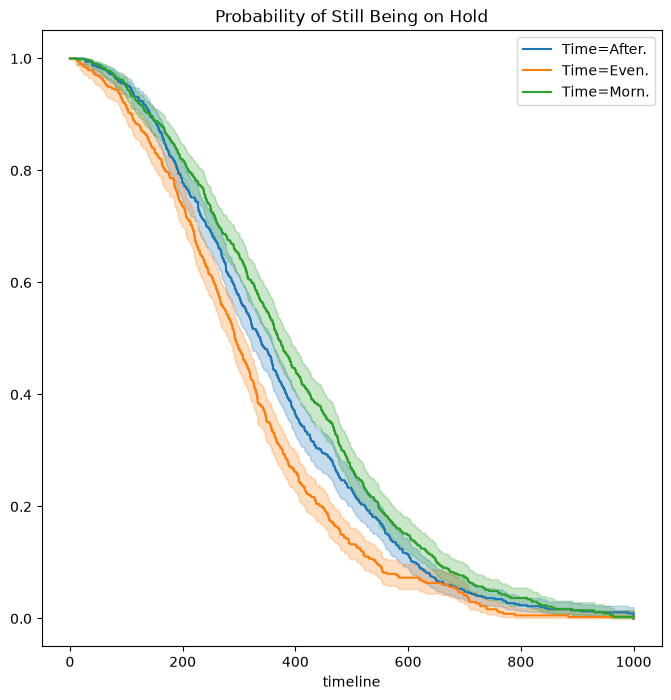

In [30]:
fig, ax = subplots(figsize=(8,8))
by_time = {}
for time, df in D.groupby('Time', observed=True):
    by_time[time] = df
    km_time = km.fit(df['Wait time'], df['Failed'])
    km_time.plot(label='Time=%s' % time, ax=ax)
ax.set_title("Probability of Still Being on Hold")

### Log-rank tests for more than two groups

`multivariate_logrank_test` extends the log-rank test to $K$ groups, with $K - 1$ degrees of
freedom. It answers only "are these curves all the same?" — a rejection does not say which group
differs, which is one reason to move to the Cox model.

In [31]:
multivariate_logrank_test(D['Wait time'],
                          D['Center'],
                          D['Failed'])

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          20.30 <0.005     14.65

In [32]:
multivariate_logrank_test(D['Wait time'],
                          D['Time'],
                          D['Failed'])

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          49.90 <0.005     35.99

The Cox likelihood ratio tests give 20.58 and 48.12 against the log-rank tests' 20.30 and 49.90 —
close but not identical. With two groups the log-rank test and the Cox score test coincide
exactly; with more groups, or when comparing the *likelihood ratio* rather than the score test,
they are asymptotically equivalent but numerically distinct. Small discrepancies like these are
expected, not errors.

In [33]:
X = MS(['Wait time',
        'Failed',
        'Center'],
       intercept=False).fit_transform(D)
F = coxph().fit(X, 'Wait time', 'Failed')
F.log_likelihood_ratio_test()

<lifelines.StatisticalResult: log-likelihood ratio test>
null_distribution = chi squared
  degrees_freedom = 2
        test_name = log-likelihood ratio test

---
 test_statistic      p  -log2(p)
          20.58 <0.005     14.85

In [34]:
X = MS(['Wait time',
        'Failed',
        'Time'],
       intercept=False).fit_transform(D)
F = coxph().fit(X, 'Wait time', 'Failed')
F.log_likelihood_ratio_test()

<lifelines.StatisticalResult: log-likelihood ratio test>
null_distribution = chi squared
  degrees_freedom = 2
        test_name = log-likelihood ratio test

---
 test_statistic      p  -log2(p)
          48.12 <0.005     34.71

### Recovering the truth

The payoff. Estimates against the values used to generate the data:

| Covariate | True $\beta$ | Estimated | SE |
|---|---|---|---|
| `Operators` | 0.04 | 0.0439 | 0.0075 |
| `Center[B]` | −0.30 | −0.2361 | 0.0581 |
| `Center[C]` | 0.00 | 0.0122 | 0.0575 |
| `Time[Even.]` | 0.20 | 0.2688 | 0.0578 |
| `Time[Morn.]` | −0.20 | −0.1482 | 0.0573 |

Every estimate lands within about one to one-and-a-half standard errors of the truth, and
`Center[C]` — the one genuinely null effect — is correctly not significant ($p = 0.83$). The Cox
model recovers the generating parameters from censored data, which is exactly what it promises.

This kind of simulation check is worth running on your own pipelines: generate data where you know
the answer, and confirm the code returns it. Bugs in survival analysis are easy to hide, since a
wrong result still looks like a plausible hazard ratio.

In [35]:
X = MS(D.columns,
       intercept=False).fit_transform(D)
fit_queuing = coxph().fit(
                  X,
                  'Wait time',
                  'Failed')
fit_queuing.summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
Operators,0.043934,0.007520,5.143589e-09
Center[B],-0.236060,0.058113,4.864162e-05
Center[C],0.012231,0.057518,8.316096e-01
Time[Even.],0.268845,0.057797,3.294956e-06
Time[Morn.],-0.148217,0.057334,9.733557e-03


---
## Summary

**Why survival methods exist**

Censored observations carry partial information "survived at least 40 months" that neither
dropping them nor treating censoring times as event times uses correctly. Kaplan-Meier and the Cox
model both handle it by working with the risk set at each event time.

**The three tools**

- **Kaplan-Meier** estimates $S(t)$ with no model assumptions. Good for description and for
  comparing a few groups; cannot adjust for covariates.
- **Log-rank test** compares curves across groups. It is exactly the score test from a Cox model
  with those group indicators, and it tells you *that* curves differ, not which or by how much.
- **Cox proportional hazards** is regression for censored outcomes. The baseline hazard stays
  unspecified; $e^{\beta_j}$ is a hazard ratio, constant over time.

**Results from this lab**

- `BrainCancer`: no sex difference ($p = 0.23$ by both tests). Diagnosis dominates HG glioma
  carries about 8.6 times the hazard of meningioma. Higher Karnofsky index means longer survival.
- `Publication`: `posres` was null unadjusted ($p = 0.36$) and strongly significant once
  confounders entered ($p = 0.001$). Adjustment changed the conclusion entirely.
- Call center: the Cox model recovered all five true coefficients within roughly one standard
  error, including correctly finding the one null effect.

**Practices worth carrying forward**

- **Verify the `status` coding before anything else.** Reversed coding produces confident, wrong
  answers with no error message.
- **Exponentiate coefficients before interpreting them.** Report hazard ratios, not log-hazards.
- **Independent censoring is an assumption, not a fact**, and it cannot be checked from the data.
  Ask why observations were censored.
- **Transform new data with the same `ModelSpec`** used for fitting, so dummy coding and column
  order match.
- **Proportional hazards is also an assumption.** Predicted curves never cross because the model
  says so. If real curves cross, the model is wrong check with Schoenfeld residuals or a
  time-varying term.
- **Simulate to validate.** Generating data with known parameters and confirming they come back
  is the most direct test that a pipeline is correct.